# 01 · Data and label audit

Inspect what the export can support before interpreting a router score. The final model response is missing, so quality labels are telemetry proxies plus a 100-case manual calibration.

In [1]:
from pathlib import Path
import csv, json, random, statistics, sys
from collections import Counter, defaultdict

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from analysis_notebook_utils import *
from IPython.display import SVG, display

def read_csv(path):
    with Path(path).open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

rows = read_csv(ROOT / 'results/calibrated_evaluation_table.csv')
usable = [r for r in rows if r['evaluation_outcome_usable'] == '1']
print(f'Rows: {len(rows):,}; usable labels: {len(usable):,}')


Rows in export: 2,000
Usable quality labels: 1,892
Task categories: 6
Logged model IDs: 8
Trajectories with explicit tool errors: 487
Trajectories with user corrections: 3


## Task mix

The scheduled-work concentration is why splits are grouped by sanitized task template rather than random rows.

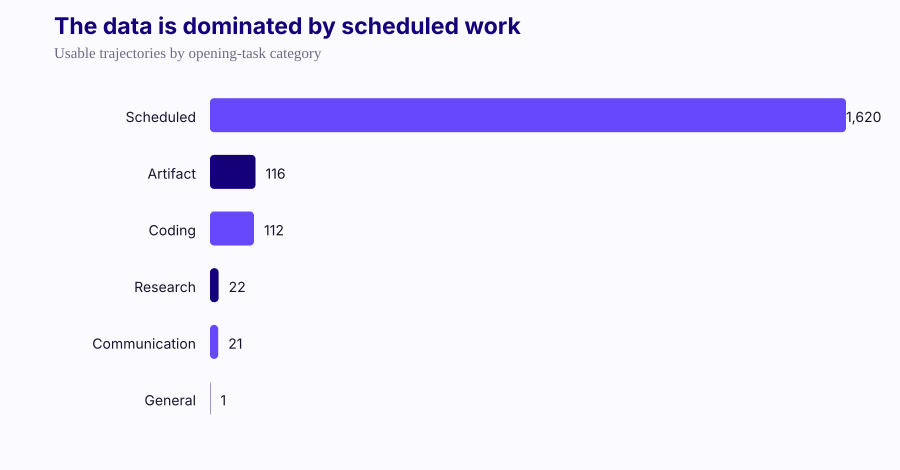

In [2]:
categories = Counter(r['x_task_category'] for r in usable)
svg = bar_chart([k.title() for k,_ in categories.most_common()], [v for _,v in categories.most_common()], 'The data is dominated by scheduled work', 'Usable trajectories by opening-task category')
display(SVG(svg))


## Natural experiment coverage

The model that ran is an observed treatment, not a correctness label. Uneven assignment makes overlap diagnostics essential.

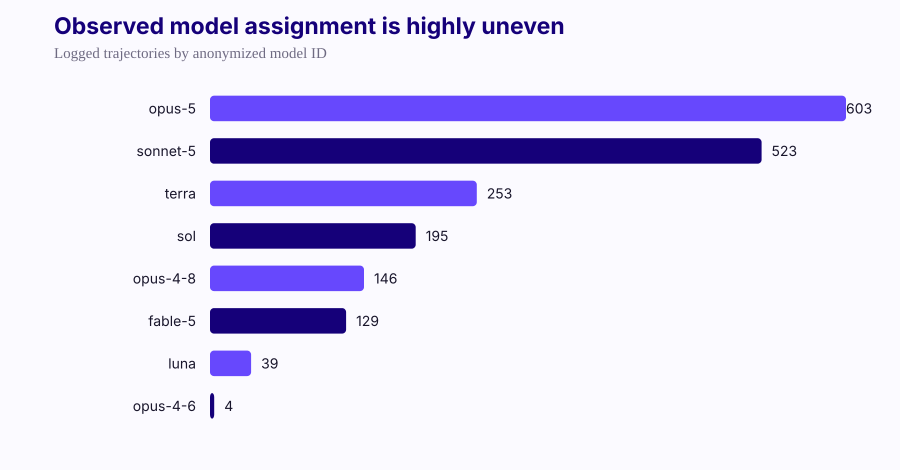

In [3]:
models = Counter(r['logged_model'] for r in usable)
svg = bar_chart([k.replace('claude-','').replace('gpt-5.6-','') for k,_ in models.most_common()], [v for _,v in models.most_common()], 'Observed model assignment is highly uneven', 'Logged trajectories by anonymized model ID')
display(SVG(svg))


## Outcome signal

Most trajectories look successful under telemetry, leaving little statistical power to prove an improvement. The goal is therefore to detect a meaningful quality loss while reducing assumed cost.

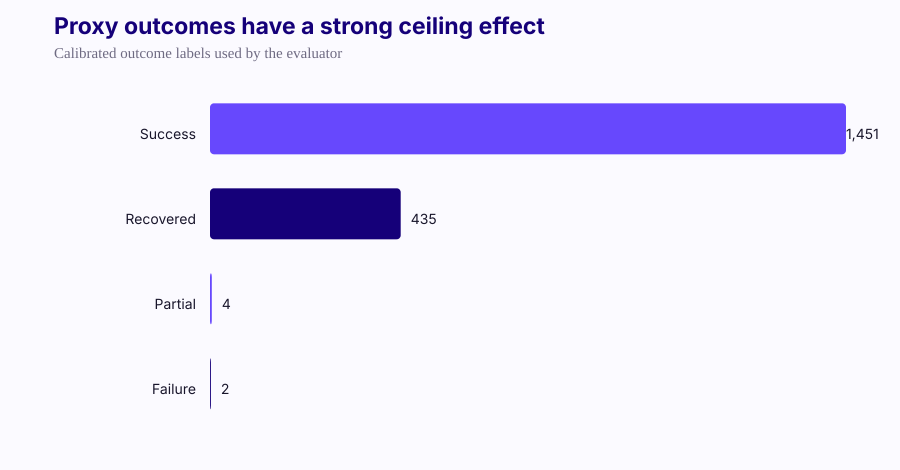

In [4]:
outcomes = Counter(r['evaluation_outcome_label'] for r in usable)
svg = bar_chart([k.title() for k,_ in outcomes.most_common()], [v for _,v in outcomes.most_common()], 'Proxy outcomes have a strong ceiling effect', 'Calibrated outcome labels used by the evaluator')
display(SVG(svg))


### Interpretation

Use this notebook to explain why raw model averages are confounded by task mix and why the final quality claim must remain cautious.